In [1]:
!pip install scikit-learn statsmodels catboost scipy -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import requests
import xml.etree.ElementTree as ET
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from catboost import CatBoostRegressor
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

In [3]:
def moex_shares(ticker, start, end):
    rows_all, s = [], 0
    while True:
        url = (f"https://iss.moex.com/iss/history/engines/stock/markets/shares"
               f"/boards/TQBR/securities/{ticker}.json?"
               f"from={start}&till={end}&start={s}")
        r = requests.get(url).json()
        rows, cols = r['history']['data'], r['history']['columns']
        if not rows:
            break
        rows_all += rows
        s += len(rows)
    if not rows_all:
        return pd.Series(dtype=float)
    df = pd.DataFrame(rows_all, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.set_index('TRADEDATE')['CLOSE'].apply(
        pd.to_numeric, errors='coerce').pipe(lambda x: x[x > 0])

def moex_index(start, end):
    rows_all, s = [], 0
    while True:
        url = (f"https://iss.moex.com/iss/history/engines/stock/markets/index"
               f"/boards/SNDX/securities/IMOEX.json?"
               f"from={start}&till={end}&start={s}")
        r = requests.get(url).json()
        rows, cols = r['history']['data'], r['history']['columns']
        if not rows:
            break
        rows_all += rows
        s += len(rows)
    df = pd.DataFrame(rows_all, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.set_index('TRADEDATE')['CLOSE'].apply(
        pd.to_numeric, errors='coerce').pipe(lambda x: x[x > 0])

def cbr_usd(start, end):
    p1, p2 = start.split('-'), end.split('-')
    d1 = f"{p1[2]}/{p1[1]}/{p1[0]}"
    d2 = f"{p2[2]}/{p2[1]}/{p2[0]}"
    url = (f"https://www.cbr.ru/scripts/XML_dynamic.asp?"
           f"date_req1={d1}&date_req2={d2}&VAL_NM_RQ=R01235")
    root = ET.fromstring(requests.get(url).content)
    recs = [(pd.to_datetime(r.attrib['Date'], dayfirst=True),
             float(r.find('Value').text.replace(',', '.')))
            for r in root.findall('Record')]
    return pd.Series(dict(recs)).sort_index()

def generate_data(t_event, tau, params, seed=None, innovation='bootstrap'):
    rng = np.random.default_rng(seed)
    p = params
    T = p['N_DAYS']
    g_vals = p['cb'].predict(p['X_real'])
    D = (np.arange(T) >= t_event).astype(float)
    if innovation == 'bootstrap':
        z = rng.choice(p['resid_std'], size=T)
    elif innovation == 't':
        df_t = p['df']
        z = (rng.standard_t(df_t, size=T) / np.sqrt(df_t / (df_t - 2))
             if df_t < 30 else rng.standard_normal(size=T))
    else:
        z = rng.standard_normal(size=T)
    eps = p['sigma'] * z
    Y_tcsg = g_vals + tau * D + eps
    df = p['feat_df'].copy()
    df[p['TREATED']] = Y_tcsg
    df['day'] = np.arange(T)
    df['post'] = (np.arange(T) >= t_event).astype(int)
    df['D'] = D
    return df

def build_ts(synth_df, params):
    controls = params['CONTROLS']
    ts = pd.DataFrame({
        'ret': synth_df[params['TREATED']].values,
        'D': synth_df['D'].values,
        'post': synth_df['post'].values,
        'day': synth_df['day'].values,
        'IMOEX': synth_df['IMOEX'].values,
        'USD_RUB': synth_df['USD_RUB'].values,
    })
    for c in controls:
        ts[c] = synth_df[c].values
    imoex = synth_df['IMOEX'].values
    ts['mkt_vol5'] = pd.Series(imoex).rolling(5).std().bfill().values
    ts['mkt_vol20'] = pd.Series(imoex).rolling(20).std().bfill().values
    ts['mkt_mom5'] = pd.Series(imoex).rolling(5).mean().bfill().values
    ts['mkt_mom20'] = pd.Series(imoex).rolling(20).mean().bfill().values
    return ts

def build_panel(synth_df, params):
    treated = params['TREATED']
    controls = params['CONTROLS']
    frames = []
    for ticker in [treated] + controls:
        tmp = pd.DataFrame({
            'ticker': ticker,
            'day': synth_df['day'].values,
            'post': synth_df['post'].values,
            'ret': synth_df[ticker].values,
            'IMOEX': synth_df['IMOEX'].values,
            'USD_RUB': synth_df['USD_RUB'].values,
        })
        frames.append(tmp)
    panel = pd.concat(frames, ignore_index=True)
    panel['treated'] = (panel['ticker'] == treated).astype(int)
    panel['did_term'] = panel['treated'] * panel['post']
    return panel

In [4]:
def event_study(ts, est_start, est_end, evt_start, evt_end):
    est = ts[(ts['day'] >= est_start) & (ts['day'] <= est_end)]
    evt = ts[(ts['day'] >= evt_start) & (ts['day'] <= evt_end)]
    if len(est) < 10 or len(evt) == 0:
        return np.nan
    slope, intercept, _, _, _ = stats.linregress(est['IMOEX'].values, est['ret'].values)
    ar = evt['ret'].values - (intercept + slope * evt['IMOEX'].values)
    return ar.sum()

def did_classic(panel):
    mod = smf.ols('ret ~ treated + post + did_term', data=panel).fit()
    return mod.params['did_term']

def dml_estimate(ts, ml_model, controls, n_folds=5, seed=42):
    Y = ts['ret'].values
    D = ts['D'].values.astype(float)
    x_cols = controls + ['IMOEX', 'USD_RUB', 'mkt_vol5', 'mkt_vol20', 'mkt_mom5', 'mkt_mom20']
    X = ts[x_cols].values
    n = len(Y)
    resid_y = np.zeros(n)
    resid_d = np.zeros(n)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for train_idx, test_idx in kf.split(X):
        my = clone(ml_model).fit(X[train_idx], Y[train_idx])
        resid_y[test_idx] = Y[test_idx] - my.predict(X[test_idx])
        md = clone(ml_model).fit(X[train_idx], D[train_idx])
        resid_d[test_idx] = D[test_idx] - md.predict(X[test_idx])
    denom = np.dot(resid_d, resid_d)
    theta = np.dot(resid_d, resid_y) / denom if denom > 0 else 0.0
    return theta

def run_all_methods(synth_df, params, est_start, est_end, evt_start, evt_end, rf_base, cb_base):
    controls = params['CONTROLS']
    ts = build_ts(synth_df, params)
    panel = build_panel(synth_df, params)
    results = {}
    results['Event Study'] = event_study(ts, est_start, est_end, evt_start, evt_end)
    results['DiD classic'] = did_classic(panel)
    results['DML + OLS'] = dml_estimate(ts, LinearRegression(), controls)
    results['DML + RF'] = dml_estimate(ts, rf_base, controls)
    results['DML + CatBoost'] = dml_estimate(ts, cb_base, controls)
    return results

In [5]:
START, END = '2023-01-01', '2025-12-31'
TREATED = 'TCSG'
CONTROLS = ['SBER', 'VTBR', 'YDEX', 'MTSS']

data = {}
old = moex_shares('TCSG', START, END)
new = moex_shares('T', START, END)
data['TCSG'] = pd.concat([old, new]).pipe(
    lambda x: x[~x.index.duplicated(keep='last')]).sort_index()
for t in CONTROLS:
    data[t] = moex_shares(t, START, END)
data['IMOEX'] = moex_index(START, END)
data['USD'] = cbr_usd(START, END).reindex(data['IMOEX'].index, method='ffill')

prices = pd.DataFrame(data).dropna()
rets = prices.pct_change().iloc[1:].replace([np.inf, -np.inf], np.nan).dropna()
N_DAYS = len(rets)

print(f"Loaded: {N_DAYS} days")

Loaded: 368 days


In [6]:
CB_PARAMS = dict(
    iterations=300, depth=4, learning_rate=0.05,
    l2_leaf_reg=3.0, verbose=0, random_seed=42,
    allow_writing_files=False,
)

imoex = rets['IMOEX'].values
usd = rets['USD'].values

feat_df = pd.DataFrame(index=rets.index)
for c in CONTROLS:
    feat_df[c] = rets[c].values
feat_df['IMOEX'] = imoex
feat_df['USD_RUB'] = usd
feat_df['mkt_vol5'] = pd.Series(imoex).rolling(5).std().bfill().values
feat_df['mkt_vol20'] = pd.Series(imoex).rolling(20).std().bfill().values
feat_df['mkt_mom5'] = pd.Series(imoex).rolling(5).mean().bfill().values
feat_df['mkt_mom20'] = pd.Series(imoex).rolling(20).mean().bfill().values

FEAT_NAMES = list(feat_df.columns)
X_real = feat_df.values
Y_real = rets[TREATED].values

cb = CatBoostRegressor(**CB_PARAMS)
cb.fit(X_real, Y_real)
r2_is = cb.score(X_real, Y_real)

reg_lin = LinearRegression().fit(X_real, Y_real)
r2_lin = reg_lin.score(X_real, Y_real)

N_FOLDS = 5
resid_oos = np.full(N_DAYS, np.nan)
r2_oos_folds = []
kf = KFold(n_splits=N_FOLDS, shuffle=False)
for train_idx, val_idx in kf.split(X_real):
    cb_fold = CatBoostRegressor(**CB_PARAMS)
    cb_fold.fit(X_real[train_idx], Y_real[train_idx])
    pred_val = cb_fold.predict(X_real[val_idx])
    resid_oos[val_idx] = Y_real[val_idx] - pred_val
    ss_res = np.sum((Y_real[val_idx] - pred_val)**2)
    ss_tot = np.sum((Y_real[val_idx] - Y_real[val_idx].mean())**2)
    r2_oos_folds.append(1 - ss_res / ss_tot if ss_tot > 0 else 0)

r2_oos = np.mean(r2_oos_folds)
sig_oos = np.nanstd(resid_oos)
resid_std_oos = resid_oos[~np.isnan(resid_oos)] / sig_oos
df_eps = np.clip(stats.t.fit(resid_std_oos)[0], 2.5, 40)

CALIBRATED = dict(
    cb=cb, feat_names=FEAT_NAMES, r2_oos=r2_oos,
    sigma=sig_oos, df=df_eps, resid_std=resid_std_oos.copy(),
    X_real=X_real.copy(), Y_real=Y_real.copy(),
    feat_df=feat_df.copy(), rets=rets.copy(),
    CONTROLS=CONTROLS, TREATED=TREATED, N_DAYS=N_DAYS,
)

print(f"R2: linear={r2_lin:.3f} CB_is={r2_is:.3f} CB_OOS={r2_oos:.3f}")
print(f"sigma_OOS={sig_oos:.5f} df={df_eps:.1f}")

R2: linear=0.805 CB_is=0.921 CB_OOS=0.724
sigma_OOS=0.01016 df=3.6


In [7]:
T_EVENT = N_DAYS // 2
EST_START = 0
EST_END = T_EVENT - 11
EVT_START = T_EVENT
EVT_END = N_DAYS - 1
N_EVENT_DAYS = EVT_END - EVT_START + 1

THETA_GRID = [0.000, 0.001, 0.003, 0.005, 0.010]
N_SIM = 500

METHOD_NAMES = [
    'Event Study',
    'DiD classic',
    'DML + OLS',
    'DML + RF',
    'DML + CatBoost',
]

rf_base = RandomForestRegressor(
    n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
cb_base = CatBoostRegressor(
    iterations=100, depth=3, learning_rate=0.1,
    verbose=0, random_seed=42, allow_writing_files=False)

print(f"T={N_DAYS}, t_event={T_EVENT}, N_EVENT_DAYS={N_EVENT_DAYS}, N_SIM={N_SIM}")

T=368, t_event=184, N_EVENT_DAYS=184, N_SIM=500


In [8]:
all_mc = {theta: {m: [] for m in METHOD_NAMES} for theta in THETA_GRID}

print(f"MC: {N_SIM} x {len(THETA_GRID)} = {N_SIM * len(THETA_GRID)}\n")
total_start = time.time()

for theta_idx, theta in enumerate(THETA_GRID):
    t0 = time.time()
    print(f"[{theta_idx+1}/{len(THETA_GRID)}] theta={theta*100:.1f}% ", end='', flush=True)

    for sim in range(N_SIM):
        seed = sim + 1000 + theta_idx * 10000
        synth_df = generate_data(T_EVENT, theta, CALIBRATED, seed=seed)
        res = run_all_methods(synth_df, CALIBRATED,
                              EST_START, EST_END, EVT_START, EVT_END,
                              rf_base, cb_base)
        for m in METHOD_NAMES:
            all_mc[theta][m].append(res.get(m, np.nan))

    print(f"({time.time()-t0:.1f}s)")

print(f"Total: {(time.time()-total_start)/60:.1f} min")

MC: 500 x 5 = 2500

[1/5] theta=0.0% (562.2s)
[2/5] theta=0.1% (559.5s)
[3/5] theta=0.3% (559.8s)
[4/5] theta=0.5% (558.9s)
[5/5] theta=1.0% (560.2s)
Total: 46.7 min


In [9]:
summary_rows = []
for theta in THETA_GRID:
    true_car = theta * N_EVENT_DAYS
    for method in METHOD_NAMES:
        arr = np.array(all_mc[theta][method])
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            continue
        target = true_car if method == 'Event Study' else theta
        mean_est = np.mean(arr)
        std_est = np.std(arr)
        bias = mean_est - target
        rmse = np.sqrt(np.mean((arr - target)**2))
        rejection_rate = np.mean(np.abs(arr / std_est) > 1.96) if std_est > 0 else 0.0
        summary_rows.append({
            'theta': theta, 'method': method, 'target': target,
            'mean': mean_est, 'std': std_est, 'bias': bias,
            'rmse': rmse, 'rejection_rate': rejection_rate,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,theta,method,target,mean,std,bias,rmse,rejection_rate
0,0.000,Event Study,0.000,-0.067403,0.195722,-0.067403,0.207003,0.048
1,0.000,DiD classic,0.000,-0.000462,0.001047,-0.000462,0.001144,0.052
2,0.000,DML + OLS,0.000,0.000124,0.001102,0.000124,0.001109,0.046
3,0.000,DML + RF,0.000,-0.001153,0.001271,-0.001153,0.001716,0.150
4,0.000,DML + CatBoost,0.000,-0.000709,0.001368,-0.000709,0.001541,0.080
5,0.001,Event Study,0.184,0.119083,0.197233,-0.064917,0.207642,0.106
6,0.001,DiD classic,0.001,0.000542,0.001073,-0.000458,0.001166,0.084
7,0.001,DML + OLS,0.001,0.001155,0.001154,0.000155,0.001164,0.170
8,0.001,DML + RF,0.001,-0.000117,0.001341,-0.001117,0.001746,0.054
9,0.001,DML + CatBoost,0.001,0.000454,0.001442,-0.000546,0.001542,0.052


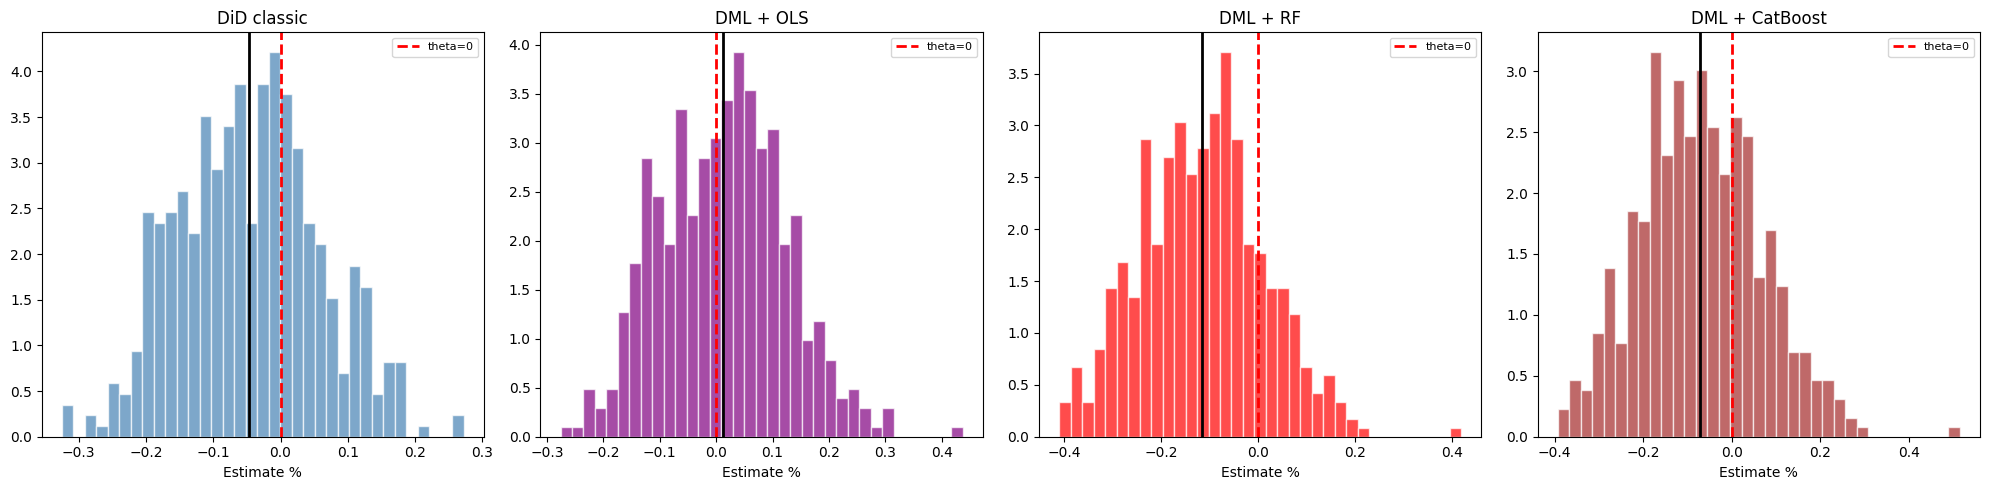

In [10]:
placebo = summary_df[(summary_df['theta'] == 0) & (summary_df['method'] != 'Event Study')]

colors_method = {
    'DiD classic': 'steelblue',
    'DML + OLS': 'purple',
    'DML + RF': 'red',
    'DML + CatBoost': 'brown',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (_, row) in enumerate(placebo.iterrows()):
    method = row['method']
    ax = axes[idx]
    arr = np.array(all_mc[0.0][method])
    arr = arr[~np.isnan(arr)]
    ax.hist(arr * 100, bins=35, color=colors_method.get(method, 'gray'),
            alpha=0.7, edgecolor='white', density=True)
    ax.axvline(0, color='red', ls='--', lw=2, label='theta=0')
    ax.axvline(np.mean(arr) * 100, color='black', ls='-', lw=2)
    ax.set_title(f'{method}')
    ax.set_xlabel('Estimate %')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

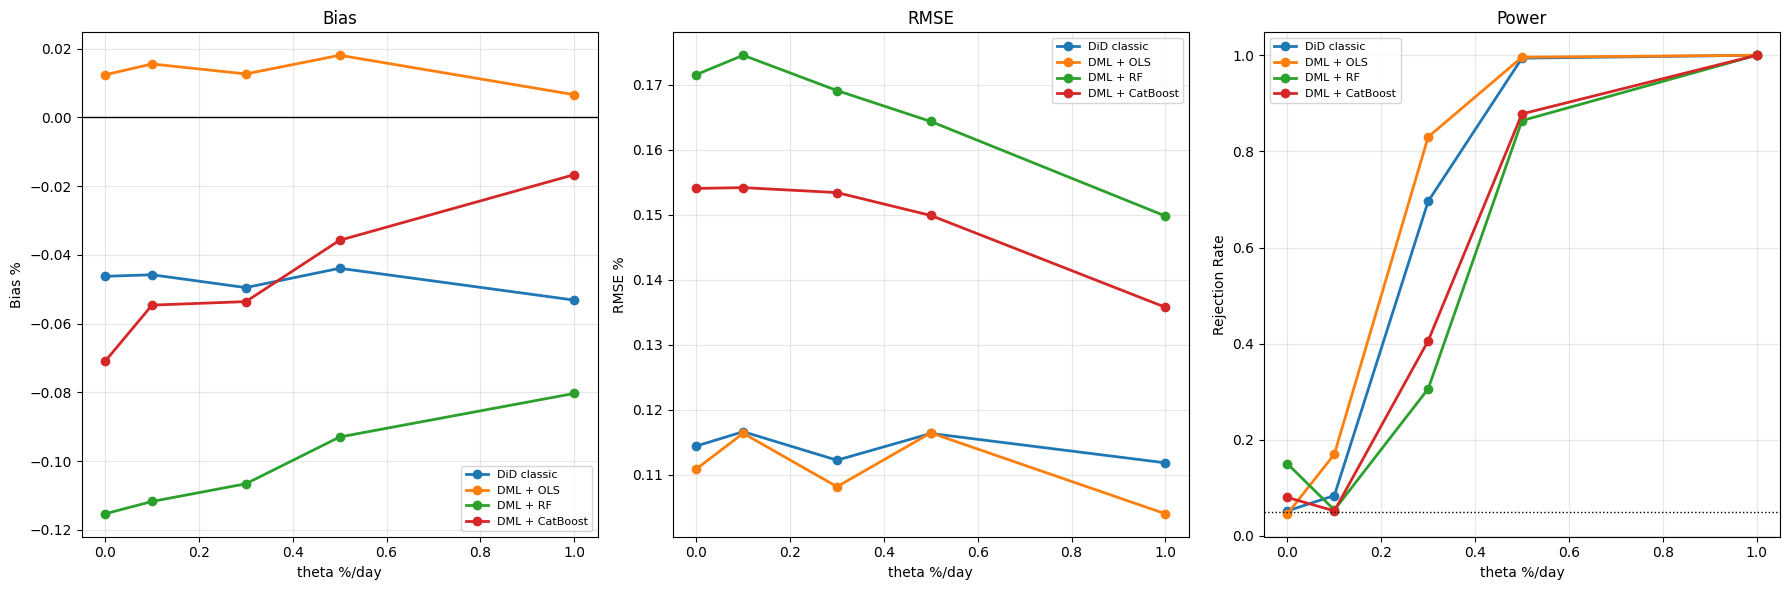

In [11]:
non_es = [m for m in METHOD_NAMES if m != 'Event Study']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
for method in non_es:
    sub = summary_df[summary_df['method'] == method]
    ax.plot(sub['theta']*100, sub['bias']*100, 'o-', label=method, lw=2, ms=6)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('theta %/day')
ax.set_ylabel('Bias %')
ax.set_title('Bias')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for method in non_es:
    sub = summary_df[summary_df['method'] == method]
    ax.plot(sub['theta']*100, sub['rmse']*100, 'o-', label=method, lw=2, ms=6)
ax.set_xlabel('theta %/day')
ax.set_ylabel('RMSE %')
ax.set_title('RMSE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
for method in non_es:
    sub = summary_df[summary_df['method'] == method]
    ax.plot(sub['theta']*100, sub['rejection_rate'], 'o-', label=method, lw=2, ms=6)
ax.axhline(0.05, color='black', ls=':', lw=1)
ax.set_xlabel('theta %/day')
ax.set_ylabel('Rejection Rate')
ax.set_title('Power')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

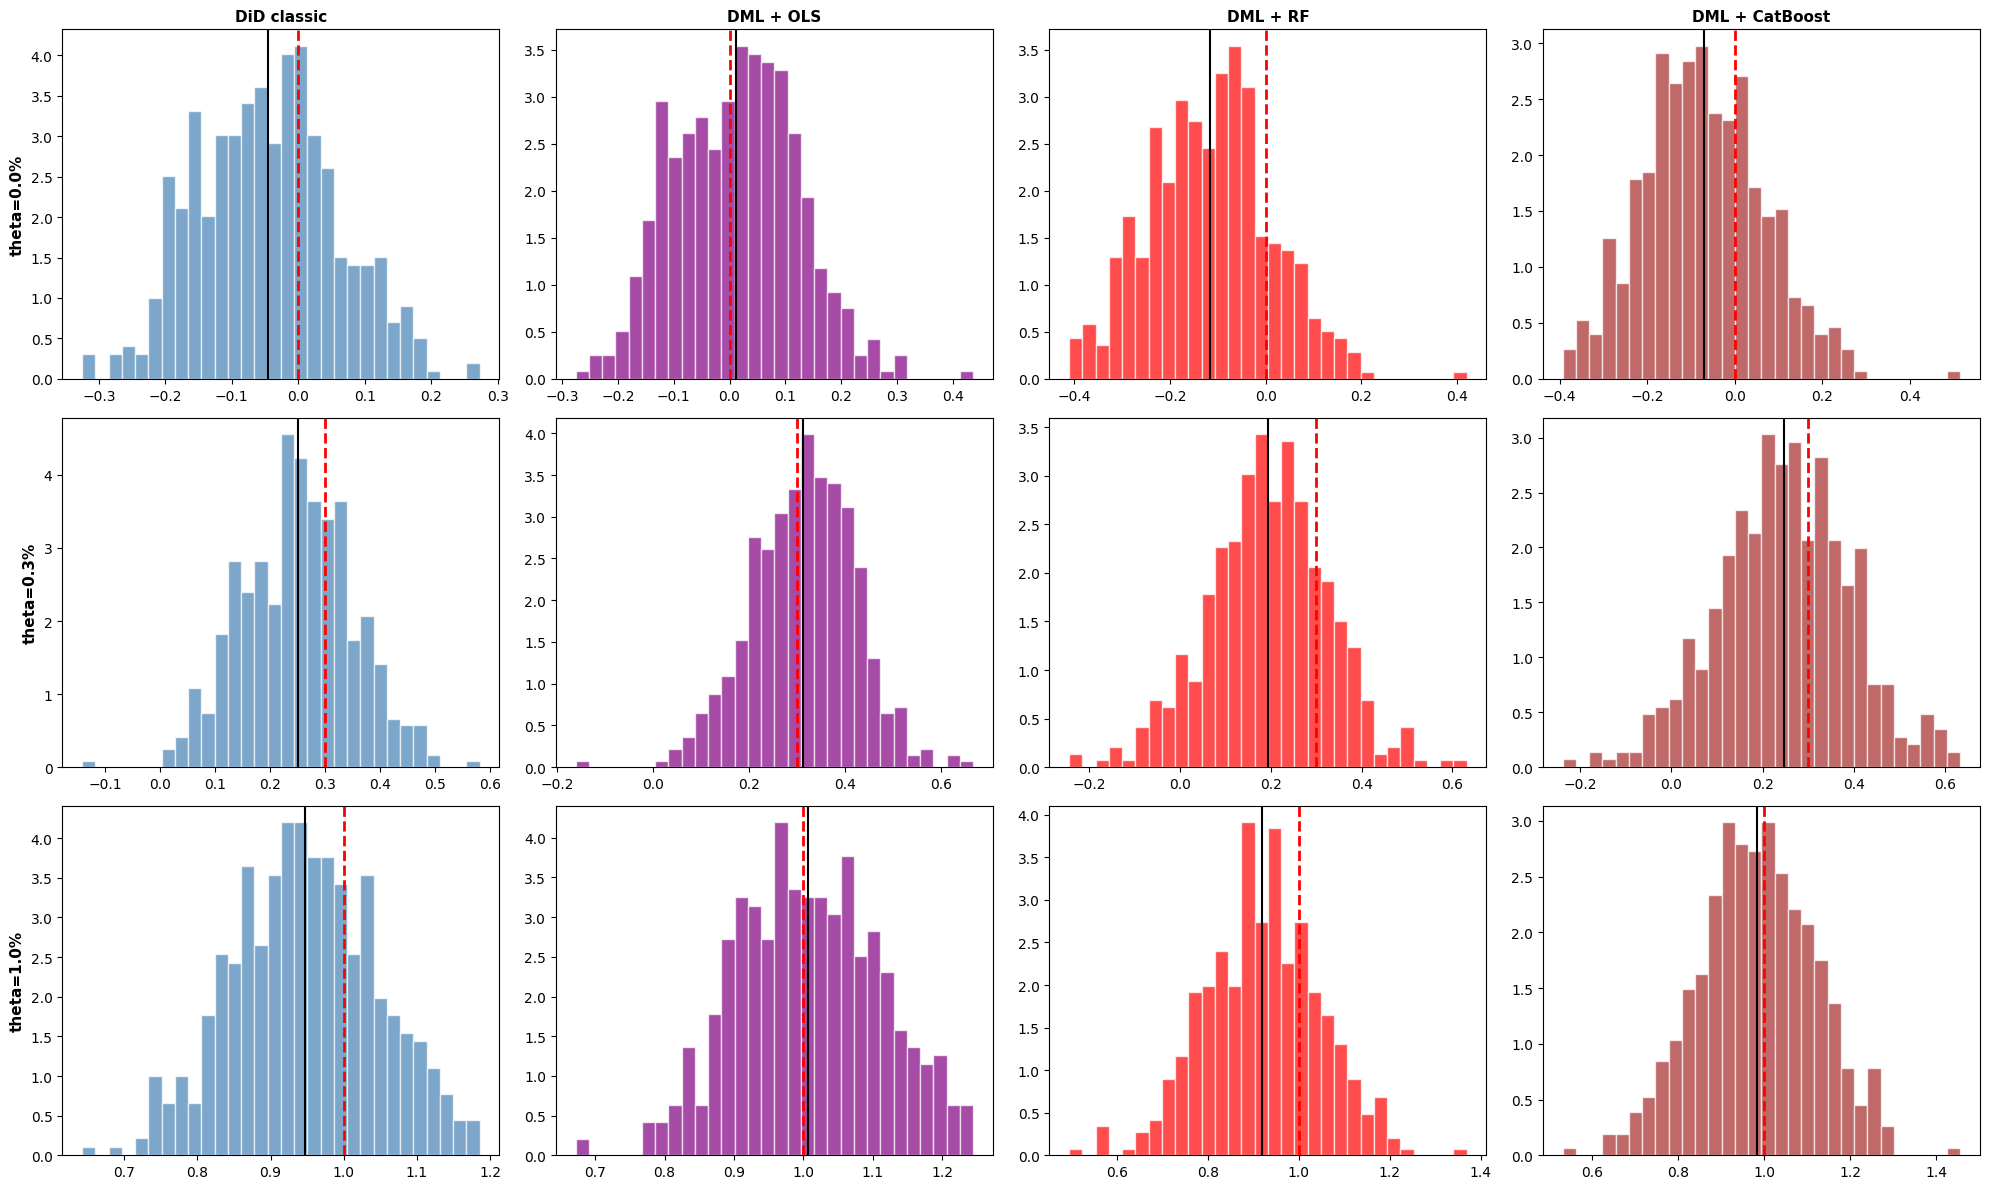

In [12]:
thetas_plot = [0.000, 0.003, 0.010]
methods_plot = ['DiD classic', 'DML + OLS', 'DML + RF', 'DML + CatBoost']

fig, axes = plt.subplots(len(thetas_plot), len(methods_plot),
                         figsize=(5*len(methods_plot), 4*len(thetas_plot)))
for i, theta in enumerate(thetas_plot):
    for j, method in enumerate(methods_plot):
        ax = axes[i, j]
        arr = np.array(all_mc[theta][method])
        arr = arr[~np.isnan(arr)]
        ax.hist(arr*100, bins=30, color=colors_method.get(method, 'gray'),
                alpha=0.7, edgecolor='white', density=True)
        ax.axvline(theta*100, color='red', ls='--', lw=2)
        ax.axvline(np.mean(arr)*100, color='black', ls='-', lw=1.5)
        if i == 0: ax.set_title(method, fontsize=11, fontweight='bold')
        if j == 0: ax.set_ylabel(f'theta={theta*100:.1f}%', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
print(f"\n{'='*100}")
print(f"RESULTS ({N_SIM} simulations)")
print(f"{'='*100}")

for theta in THETA_GRID:
    sub = summary_df[(summary_df['theta'] == theta) &
                     (summary_df['method'] != 'Event Study')]
    print(f"\ntheta = {theta*100:.1f}%/day")
    print(f"{'-'*100}")
    print(f"  {'Method':<22} {'Mean(%)':<12} {'Std(%)':<12} {'Bias(%)':<12} {'RMSE(%)':<12} {'Power':<10}")
    print(f"  {'-'*80}")
    
    sub_sorted = sub.sort_values('rmse')
    for _, row in sub_sorted.iterrows():
        print(f"  {row['method']:<22} {row['mean']*100:<12.4f} {row['std']*100:<12.4f} "
              f"{row['bias']*100:<12.4f} {row['rmse']*100:<12.4f} {row['rejection_rate']:<10.1%}")

print(f"\nEvent Study (CAR)")
print(f"{'-'*100}")
print(f"  {'theta %/day':<15} {'True CAR%':<15} {'Mean CAR%':<15} {'Bias%':<15} {'RMSE%':<15}")
for theta in THETA_GRID:
    es = summary_df[(summary_df['theta'] == theta) & (summary_df['method'] == 'Event Study')]
    if len(es) > 0:
        row = es.iloc[0]
        print(f"  {theta*100:<15.1f} {row['target']*100:<15.2f} {row['mean']*100:<15.2f} "
              f"{row['bias']*100:<15.2f} {row['rmse']*100:<15.2f}")

print(f"\n{'='*100}")
print(f"Average ranking (theta > 0)")
print(f"{'='*100}")
avg = (summary_df[(summary_df['theta']>0)&(summary_df['method']!='Event Study')]
       .groupby('method')
       .agg({'rmse':'mean', 'bias':'mean', 'std':'mean', 'rejection_rate':'mean'})
       .sort_values('rmse'))
for rank, (method, row) in enumerate(avg.iterrows(), 1):
    print(f"  {rank}. {method:<20} RMSE={row['rmse']*100:.4f}% Bias={row['bias']*100:.4f}% "
          f"Std={row['std']*100:.4f}% Power={row['rejection_rate']:.1%}")


RESULTS (500 simulations)

theta = 0.0%/day
----------------------------------------------------------------------------------------------------
  Method                 Mean(%)      Std(%)       Bias(%)      RMSE(%)      Power     
  --------------------------------------------------------------------------------
  DML + OLS              0.0124       0.1102       0.0124       0.1109       4.6%      
  DiD classic            -0.0462      0.1047       -0.0462      0.1144       5.2%      
  DML + CatBoost         -0.0709      0.1368       -0.0709      0.1541       8.0%      
  DML + RF               -0.1153      0.1271       -0.1153      0.1716       15.0%     

theta = 0.1%/day
----------------------------------------------------------------------------------------------------
  Method                 Mean(%)      Std(%)       Bias(%)      RMSE(%)      Power     
  --------------------------------------------------------------------------------
  DML + OLS              0.1155       0.1

In [14]:
best_by_theta = []
for theta in THETA_GRID:
    sub = summary_df[summary_df['theta'] == theta]
    best = sub.loc[sub['rmse'].idxmin()]
    
    print(f"\ntheta={theta*100:.1f}%")
    print(f"{'theta':<10} {'Method':<20} {'Power %':<12} {'RMSE %':<12} {'Bias %':<12}")
    print(f"{'-'*56}")
    print(f"{theta*100:<10.1f} {best['method']:<20} {best['rejection_rate']*100:<12.1f} "
          f"{best['rmse']*100:<12.4f} {best['bias']*100:<12.4f}")
    
    best_by_theta.append({
        'theta': f"{theta*100:.1f}%",
        'method': best['method'],
        'power': f"{best['rejection_rate']*100:.1f}%",
        'rmse': f"{best['rmse']*100:.4f}%",
        'bias': f"{best['bias']*100:.4f}%",
    })

avg_metrics = (summary_df[(summary_df['theta']>0)]
               .groupby('method')
               .agg({'rmse':'mean', 'bias':'mean', 'std':'mean', 'rejection_rate':'mean'})
               .sort_values('rmse'))


theta=0.0%
theta      Method               Power %      RMSE %       Bias %      
--------------------------------------------------------
0.0        DML + OLS            4.6          0.1109       0.0124      

theta=0.1%
theta      Method               Power %      RMSE %       Bias %      
--------------------------------------------------------
0.1        DML + OLS            17.0         0.1164       0.0155      

theta=0.3%
theta      Method               Power %      RMSE %       Bias %      
--------------------------------------------------------
0.3        DML + OLS            83.0         0.1082       0.0126      

theta=0.5%
theta      Method               Power %      RMSE %       Bias %      
--------------------------------------------------------
0.5        DiD classic          99.4         0.1164       -0.0439     

theta=1.0%
theta      Method               Power %      RMSE %       Bias %      
--------------------------------------------------------
1.0        DML +

In [15]:
avg_metrics_for_file = []
for method, row in avg_metrics.iterrows():
    print(f"{method:<20} {row['rmse']*100:<12.4f} {row['bias']*100:<12.4f} "
          f"{row['std']*100:<12.4f} {row['rejection_rate']*100:<12.1f}")
    
    avg_metrics_for_file.append({
        'Method': method,
        'RMSE (%)': f"{row['rmse']*100:.4f}",
        'Bias (%)': f"{row['bias']*100:.4f}",
        'Std (%)': f"{row['std']*100:.4f}",
        'Power (%)': f"{row['rejection_rate']*100:.1f}",
    })

DML + OLS            0.1113       0.0132       0.1104       74.9        
DiD classic          0.1143       -0.0481      0.1036       69.3        
DML + CatBoost       0.1483       -0.0401      0.1421       58.4        
DML + RF             0.1645       -0.0979      0.1319       55.6        
Event Study          20.5383      -6.9779      19.2936      70.8        


In [16]:
df_best = pd.DataFrame(best_by_theta)
df_avg = pd.DataFrame(avg_metrics_for_file)

In [17]:
df_best

,theta,method,power,rmse,bias
0,0.0%,DML + OLS,4.6%,0.1109%,0.0124%
1,0.1%,DML + OLS,17.0%,0.1164%,0.0155%
2,0.3%,DML + OLS,83.0%,0.1082%,0.0126%
3,0.5%,DiD classic,99.4%,0.1164%,-0.0439%
4,1.0%,DML + OLS,100.0%,0.1040%,0.0066%


In [18]:
df_avg

,Method,RMSE (%),Bias (%),Std (%),Power (%)
0,DML + OLS,0.1113,0.0132,0.1104,74.9
1,DiD classic,0.1143,-0.0481,0.1036,69.3
2,DML + CatBoost,0.1483,-0.0401,0.1421,58.4
3,DML + RF,0.1645,-0.0979,0.1319,55.6
4,Event Study,20.5383,-6.9779,19.2936,70.8


In [19]:
df_avg.to_csv('average_metrics_by_method.csv', index=False)
df_best.to_csv('best_method_by_theta.csv', index=False)

In [20]:
rows = []

for method in METHOD_NAMES:
    for theta in THETA_GRID:
        sub = summary_df[(summary_df['theta'] == theta) & (summary_df['method'] == method)]
        if len(sub) > 0:
            row = sub.iloc[0]
            rows.append({
                'theta': f"{theta*100:.1f}%",
                'method': method,
                'rmse': f"{row['rmse']*100:.4f}",
                'bias': f"{row['bias']*100:.4f}",
                'std': f"{row['std']*100:.4f}",
                'power': f"{row['rejection_rate']*100:.1f}",
            })

df_metrics = pd.DataFrame(rows)
df_metrics

,theta,method,rmse,bias,std,power
0,0.0%,Event Study,20.7003,-6.7403,19.5722,4.8
1,0.1%,Event Study,20.7642,-6.4917,19.7233,10.6
2,0.3%,Event Study,19.9460,-7.2370,18.5868,73.2
3,0.5%,Event Study,21.4173,-6.1874,20.5040,99.2
4,1.0%,Event Study,20.0257,-7.9954,18.3603,100.0
5,0.0%,DiD classic,0.1144,-0.0462,0.1047,5.2
6,0.1%,DiD classic,0.1166,-0.0458,0.1073,8.4
7,0.3%,DiD classic,0.1123,-0.0495,0.1008,69.6
8,0.5%,DiD classic,0.1164,-0.0439,0.1078,99.4
9,1.0%,DiD classic,0.1119,-0.0531,0.0984,100.0


In [21]:
df_metrics.to_csv('metrics_by_method_theta.csv', index=False)